#Cleaning Zillow Dataset (Core: State-Level Home Values)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
import pandas as pd

folder_path = '/content/drive/MyDrive/Colab Notebooks/DVN 36104/Datasets'

zillow_path = os.path.join(folder_path, 'State_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv')
df_zillow = pd.read_csv(zillow_path)

print(df_zillow.shape)
df_zillow.head()

(51, 320)


,RegionID,SizeRank,RegionName,RegionType,StateName,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31,...,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31,2026-02-28,2026-03-31
0,9,0,California,state,NaN,190505.645708,191145.992046,192010.616404,193887.458080,196069.003800,...,774165.264348,771254.167991,769281.885868,768851.715494,769615.066469,771309.858283,773638.892223,774927.326494,775286.636344,774581.730955
1,54,1,Texas,state,NaN,114281.423664,114343.527142,114373.648302,114523.142288,114619.956937,...,304176.986473,303109.368172,302271.536772,301755.691535,301384.310007,301229.043640,301242.235494,301264.288545,301244.070183,300957.464111
2,14,2,Florida,state,NaN,108360.737955,108595.457400,108879.984155,109458.353866,110082.063273,...,384663.841421,381871.631335,379374.056928,377586.987288,376429.604782,375741.892161,375386.648283,375381.759057,375565.265605,375661.545263
3,43,3,New York,state,NaN,150938.088920,151475.576785,151992.995533,153105.822601,154257.200815,...,488616.363493,490511.265498,492158.599376,493960.495173,495924.481907,498297.120033,500672.490242,502770.061083,505147.795630,507794.278955
4,47,4,Pennsylvania,state,NaN,99561.173876,99774.127687,99974.247066,100382.059952,100800.985898,...,277089.373231,277865.369227,278588.434174,279393.221626,279716.346114,280171.052363,280751.173176,281492.500322,282198.523896,282735.920995


In [3]:
#sanity check: confirming state amount: 50 states and the District of Columbia
df_zillow['RegionType'].value_counts()


,count
RegionType,
state,51


In [4]:
# Convert the Zillow dataset from wide format to long format.
# The original table has one row per state and one column for each monthly date.
# This step reshapes the dataset so that each row represents one state in one month,
# which makes the data easier to clean, analyze, visualize, and merge with other monthly datasets.
id_cols = ['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName']
date_cols = [col for col in df_zillow.columns if col not in id_cols]

zillow_long = df_zillow.melt(
    id_vars=id_cols,
    value_vars=date_cols,
    var_name='date',
    value_name='home_value'
)

print(zillow_long.shape)
zillow_long.head()

(16065, 7)


,RegionID,SizeRank,RegionName,RegionType,StateName,date,home_value
0,9,0,California,state,NaN,2000-01-31,190505.645708
1,54,1,Texas,state,NaN,2000-01-31,114281.423664
2,14,2,Florida,state,NaN,2000-01-31,108360.737955
3,43,3,New York,state,NaN,2000-01-31,150938.088920
4,47,4,Pennsylvania,state,NaN,2000-01-31,99561.173876


In [5]:
# Convert the date column to datetime format
# so it can be filtered and used in time-series analysis.
zillow_long['date'] = pd.to_datetime(zillow_long['date'])

print(zillow_long['date'].min())
print(zillow_long['date'].max())

2000-01-31 00:00:00
2026-03-31 00:00:00


In [6]:
# Keep only the project period from January 2024 to February 2026.
zillow_filtered = zillow_long[
    (zillow_long['date'] >= '2024-01-01') &
    (zillow_long['date'] <= '2026-02-28')
].copy()

print(zillow_filtered.shape)
zillow_filtered.head()

(1326, 7)


,RegionID,SizeRank,RegionName,RegionType,StateName,date,home_value
14688,9,0,California,state,NaN,2024-01-31,766370.813897
14689,54,1,Texas,state,NaN,2024-01-31,308842.571167
14690,14,2,Florida,state,NaN,2024-01-31,400358.633247
14691,43,3,New York,state,NaN,2024-01-31,452046.162203
14692,47,4,Pennsylvania,state,NaN,2024-01-31,263290.887304


In [7]:
# Keep only the columns needed for analysis
# and rename RegionName to state for clarity.
zillow_clean = zillow_filtered[['RegionName', 'date', 'home_value']].copy()
zillow_clean = zillow_clean.rename(columns={'RegionName': 'state'})

zillow_clean['year'] = zillow_clean['date'].dt.year
zillow_clean['month'] = zillow_clean['date'].dt.month
zillow_clean['year_month'] = zillow_clean['date'].dt.to_period('M').astype(str)

print(zillow_clean.shape)
zillow_clean.head()

(1326, 6)


,state,date,home_value,year,month,year_month
14688,California,2024-01-31,766370.813897,2024,1,2024-01
14689,Texas,2024-01-31,308842.571167,2024,1,2024-01
14690,Florida,2024-01-31,400358.633247,2024,1,2024-01
14691,New York,2024-01-31,452046.162203,2024,1,2024-01
14692,Pennsylvania,2024-01-31,263290.887304,2024,1,2024-01


In [8]:
print(zillow_clean['state'].nunique())
print(zillow_clean['date'].min(), zillow_clean['date'].max())
print(zillow_clean.isna().sum())

51
2024-01-31 00:00:00 2026-02-28 00:00:00
state         0
date          0
home_value    0
year          0
month         0
year_month    0
dtype: int64


- **Core Dataset After Cleaning: one record represents one state’s home value for one month, covering the period from January 2024 to February 2026.**

#Cleaning BLS Dataset (Enrich: State-Level Employment and Unemployment)

In [9]:
# Read the BLS file by skipping the title/header rows
# and manually assigning clean column names.

bls_path = os.path.join(folder_path, 'state_employment_unemployment_bls_monthly.xlsx')

bls_cols = [
    'fips_code',
    'state',
    'year',
    'month',
    'civilian_population',
    'labor_force_total',
    'labor_force_participation_rate',
    'employment_total',
    'employment_population_ratio',
    'unemployment_total',
    'unemployment_rate'
]

df_bls = pd.read_excel(
    bls_path,
    skiprows=7,      # data starts after the multi-row header
    header=None,
    names=bls_cols
)

print(df_bls.shape)
df_bls.head()

(31856, 11)


,fips_code,state,year,month,civilian_population,labor_force_total,labor_force_participation_rate,employment_total,employment_population_ratio,unemployment_total,unemployment_rate
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,01,Alabama,1976.0,1.0,2605000,1486509,57.1,1387606,53.3,98903,6.7
2,02,Alaska,1976.0,1.0,232000,160709,69.3,149226,64.3,11483,7.1
3,04,Arizona,1976.0,1.0,1621000,963980,59.5,865261,53.4,98719,10.2
4,05,Arkansas,1976.0,1.0,1536000,889912,57.9,825233,53.7,64679,7.3


In [10]:
df_bls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31856 entries, 0 to 31855
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   fips_code                       31854 non-null  object 
 1   state                           31853 non-null  object 
 2   year                            31853 non-null  float64
 3   month                           31853 non-null  float64
 4   civilian_population             31853 non-null  object 
 5   labor_force_total               31853 non-null  object 
 6   labor_force_participation_rate  31853 non-null  object 
 7   employment_total                31853 non-null  object 
 8   employment_population_ratio     31853 non-null  object 
 9   unemployment_total              31853 non-null  object 
 10  unemployment_rate               31853 non-null  object 
dtypes: float64(2), object(9)
memory usage: 2.7+ MB


In [11]:
# Keep only the 50 states and the District of Columbia.
valid_states = [
    'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
    'Connecticut', 'Delaware', 'District of Columbia', 'Florida', 'Georgia',
    'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky',
    'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
    'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire',
    'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota',
    'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island',
    'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont',
    'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming'
]

df_bls = df_bls[df_bls['state'].isin(valid_states)].copy()

print(df_bls.shape)
print(df_bls['state'].nunique())

(30651, 11)
51


In [12]:
# Convert year and month to integers.
df_bls['year'] = pd.to_numeric(df_bls['year'], errors='coerce')
df_bls['month'] = pd.to_numeric(df_bls['month'], errors='coerce')

df_bls['year'] = df_bls['year'].astype(int)
df_bls['month'] = df_bls['month'].astype(int)

df_bls[['year', 'month']].head()

,year,month
1,1976,1
2,1976,1
3,1976,1
4,1976,1
5,1976,1


In [13]:
# Convert BLS numeric columns to numeric format.
numeric_cols = [
    'civilian_population',
    'labor_force_total',
    'labor_force_participation_rate',
    'employment_total',
    'employment_population_ratio',
    'unemployment_total',
    'unemployment_rate'
]

for col in numeric_cols:
    df_bls[col] = (
        df_bls[col]
        .astype(str)
        .str.replace(',', '', regex=False)
        .str.strip()
    )
    df_bls[col] = pd.to_numeric(df_bls[col], errors='coerce')

df_bls[numeric_cols].head()

,civilian_population,labor_force_total,labor_force_participation_rate,employment_total,employment_population_ratio,unemployment_total,unemployment_rate
1,2605000.0,1486509.0,57.1,1387606.0,53.3,98903.0,6.7
2,232000.0,160709.0,69.3,149226.0,64.3,11483.0,7.1
3,1621000.0,963980.0,59.5,865261.0,53.4,98719.0,10.2
4,1536000.0,889912.0,57.9,825233.0,53.7,64679.0,7.3
5,15621000.0,9770553.0,62.5,8873133.0,56.8,897420.0,9.2


In [14]:
# Create year_month and date fields for merging.
df_bls['year_month'] = (
    df_bls['year'].astype(str) + '-' + df_bls['month'].astype(str).str.zfill(2)
)

df_bls['date'] = pd.to_datetime(df_bls['year_month'] + '-01') + pd.offsets.MonthEnd(0)

df_bls[['state', 'year', 'month', 'year_month', 'date']].head()

,state,year,month,year_month,date
1,Alabama,1976,1,1976-01,1976-01-31
2,Alaska,1976,1,1976-01,1976-01-31
3,Arizona,1976,1,1976-01,1976-01-31
4,Arkansas,1976,1,1976-01,1976-01-31
5,California,1976,1,1976-01,1976-01-31


In [15]:
# Keep only the project period from January 2024 to February 2026.
df_bls = df_bls[
    (df_bls['date'] >= '2024-01-01') &
    (df_bls['date'] <= '2026-02-28')
].copy()

print(df_bls.shape)
print(df_bls['date'].min(), df_bls['date'].max())

(1275, 13)
2024-01-31 00:00:00 2026-01-31 00:00:00


In [16]:
df_bls[df_bls['year_month'] == '2025-10'].isna().sum()

,0
fips_code,0
state,0
year,0
month,0
civilian_population,51
labor_force_total,51
labor_force_participation_rate,51
employment_total,51
employment_population_ratio,51
unemployment_total,51


##Imputation for 2025.10 and 2026.02

In [17]:
# Create missing 2026-02 rows for each state
states_202602 = df_bls[['state']].drop_duplicates().copy()
states_202602['year'] = 2026
states_202602['month'] = 2
states_202602['year_month'] = '2026-02'
states_202602['date'] = pd.to_datetime('2026-02-28')

# Keep BLS metric columns empty for now
for col in numeric_cols:
    states_202602[col] = pd.NA

# Keep fips_code empty for the added rows
states_202602['fips_code'] = pd.NA

# Reorder columns to match df_bls
states_202602 = states_202602[df_bls.columns]

# Append the missing month
bls_extended = pd.concat([df_bls, states_202602], ignore_index=True)

print(bls_extended.shape)
print(bls_extended['year_month'].value_counts().sort_index().tail())

(1326, 13)
year_month
2025-10    51
2025-11    51
2025-12    51
2026-01    51
2026-02    51
Name: count, dtype: int64


/tmp/ipykernel_53849/2082693867.py:19: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  bls_extended = pd.concat([df_bls, states_202602], ignore_index=True)


In [18]:
# Forward-fill BLS values within each state
bls_imputed = bls_extended.sort_values(['state', 'date']).copy()

bls_imputed[numeric_cols] = (
    bls_imputed
    .groupby('state')[numeric_cols]
    .ffill()
)

print(bls_imputed[numeric_cols].isna().sum())

civilian_population               0
labor_force_total                 0
labor_force_participation_rate    0
employment_total                  0
employment_population_ratio       0
unemployment_total                0
unemployment_rate                 0
dtype: int64


In [19]:
bls_imputed[
    bls_imputed['year_month'].isin(['2025-10', '2026-02'])
][['state', 'year_month', 'unemployment_rate']].head(20)

,state,year_month,unemployment_rate
1071,Alabama,2025-10,2.8
1275,Alabama,2026-02,2.7
1072,Alaska,2025-10,4.7
1276,Alaska,2026-02,4.8
1073,Arizona,2025-10,4.4
1277,Arizona,2026-02,4.5
1074,Arkansas,2025-10,4.2
1278,Arkansas,2026-02,4.4
1075,California,2025-10,5.5
1279,California,2026-02,5.4


In [20]:
# Reorder columns for the final imputed BLS dataset
bls_imputed = bls_imputed[
    [
        'state',
        'date',
        'year',
        'month',
        'year_month',
        'civilian_population',
        'labor_force_total',
        'labor_force_participation_rate',
        'employment_total',
        'employment_population_ratio',
        'unemployment_total',
        'unemployment_rate'
    ]
].copy()

print(bls_imputed.shape)
bls_imputed.head()

(1326, 12)


,state,date,year,month,year_month,civilian_population,labor_force_total,labor_force_participation_rate,employment_total,employment_population_ratio,unemployment_total,unemployment_rate
0,Alabama,2024-01-31,2024,1,2024-01,4078153.0,2341587.0,57.4,2274517.0,55.8,67070.0,2.9
51,Alabama,2024-02-29,2024,2,2024-02,4081272.0,2344465.0,57.4,2277047.0,55.8,67418.0,2.9
102,Alabama,2024-03-31,2024,3,2024-03,4084816.0,2347252.0,57.5,2279641.0,55.8,67611.0,2.9
153,Alabama,2024-04-30,2024,4,2024-04,4088407.0,2350202.0,57.5,2282284.0,55.8,67918.0,2.9
204,Alabama,2024-05-31,2024,5,2024-05,4092050.0,2353106.0,57.5,2284687.0,55.8,68419.0,2.9


#Cleaning FRED Dataset (Enrich: 30-Year Fixed Mortgage Rate)

In [21]:
fred_path = os.path.join(folder_path, 'mortgage_rate_30yr_us_weekly_2024_2026.csv')
df_fred = pd.read_csv(fred_path)

print(df_fred.shape)
df_fred.head()

(113, 2)


,observation_date,MORTGAGE30US
0,2024-01-04,6.62
1,2024-01-11,6.66
2,2024-01-18,6.60
3,2024-01-25,6.69
4,2024-02-01,6.63


In [22]:
# Convert the FRED mortgage rate series from WEEKLY TO MONTHLY data
# by taking the average mortgage rate within each month.

df_fred['observation_date'] = pd.to_datetime(df_fred['observation_date'])

fred_monthly = (
    df_fred
    .groupby(df_fred['observation_date'].dt.to_period('M'))['MORTGAGE30US']
    .mean()
    .reset_index()
)

fred_monthly = fred_monthly.rename(columns={
    'observation_date': 'year_month',
    'MORTGAGE30US': 'mortgage_rate'
})

fred_monthly['year_month'] = fred_monthly['year_month'].astype(str)
fred_monthly['date'] = pd.to_datetime(fred_monthly['year_month'] + '-01') + pd.offsets.MonthEnd(0)
fred_monthly['year'] = fred_monthly['date'].dt.year
fred_monthly['month'] = fred_monthly['date'].dt.month

fred_monthly = fred_monthly[['date', 'year', 'month', 'year_month', 'mortgage_rate']].copy()

print(fred_monthly.shape)
fred_monthly.head()

(26, 5)


,date,year,month,year_month,mortgage_rate
0,2024-01-31,2024,1,2024-01,6.6425
1,2024-02-29,2024,2,2024-02,6.7760
2,2024-03-31,2024,3,2024-03,6.8200
3,2024-04-30,2024,4,2024-04,6.9925
4,2024-05-31,2024,5,2024-05,7.0600


In [23]:
print(fred_monthly['date'].min(), fred_monthly['date'].max())
print(fred_monthly.isna().sum())

2024-01-31 00:00:00 2026-02-28 00:00:00
date             0
year             0
month            0
year_month       0
mortgage_rate    0
dtype: int64


#MERGE

In [24]:
master_df_imputed = pd.merge(
    zillow_clean,
    bls_imputed,
    on=['state', 'year_month'],
    how='left',
    suffixes=('', '_bls')
)

master_df_imputed = pd.merge(
    master_df_imputed,
    fred_monthly[['year_month', 'mortgage_rate']],
    on='year_month',
    how='left'
)

# Drop duplicate BLS time columns
cols_to_drop = [col for col in ['date_bls', 'year_bls', 'month_bls'] if col in master_df_imputed.columns]
master_df_imputed = master_df_imputed.drop(columns=cols_to_drop)

print(master_df_imputed.shape)
print(master_df_imputed.isna().sum())
master_df_imputed.head()

(1326, 14)
state                             0
date                              0
home_value                        0
year                              0
month                             0
year_month                        0
civilian_population               0
labor_force_total                 0
labor_force_participation_rate    0
employment_total                  0
employment_population_ratio       0
unemployment_total                0
unemployment_rate                 0
mortgage_rate                     0
dtype: int64


,state,date,home_value,year,month,year_month,civilian_population,labor_force_total,labor_force_participation_rate,employment_total,employment_population_ratio,unemployment_total,unemployment_rate,mortgage_rate
0,California,2024-01-31,766370.813897,2024,1,2024-01,31535823.0,19611227.0,62.2,18607378.0,59.0,1003849.0,5.1,6.6425
1,Texas,2024-01-31,308842.571167,2024,1,2024-01,23875494.0,15429166.0,64.6,14818390.0,62.1,610776.0,4.0,6.6425
2,Florida,2024-01-31,400358.633247,2024,1,2024-01,18878106.0,11100291.0,58.8,10751001.0,56.9,349290.0,3.1,6.6425
3,New York,2024-01-31,452046.162203,2024,1,2024-01,16243346.0,9894797.0,60.9,9485047.0,58.4,409750.0,4.1,6.6425
4,Pennsylvania,2024-01-31,263290.887304,2024,1,2024-01,10569867.0,6609810.0,62.5,6365227.0,60.2,244583.0,3.7,6.6425


In [25]:
# Final check: overall structure
print(master_df_imputed.shape)
print(master_df_imputed[['state', 'year_month']].duplicated().sum())
print(master_df_imputed.columns.tolist())

(1326, 14)
0
['state', 'date', 'home_value', 'year', 'month', 'year_month', 'civilian_population', 'labor_force_total', 'labor_force_participation_rate', 'employment_total', 'employment_population_ratio', 'unemployment_total', 'unemployment_rate', 'mortgage_rate']


In [26]:
master_df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1326 entries, 0 to 1325
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   state                           1326 non-null   object        
 1   date                            1326 non-null   datetime64[ns]
 2   home_value                      1326 non-null   float64       
 3   year                            1326 non-null   int32         
 4   month                           1326 non-null   int32         
 5   year_month                      1326 non-null   object        
 6   civilian_population             1326 non-null   float64       
 7   labor_force_total               1326 non-null   float64       
 8   labor_force_participation_rate  1326 non-null   float64       
 9   employment_total                1326 non-null   float64       
 10  employment_population_ratio     1326 non-null   float64       
 11  unem

In [27]:
print(master_df_imputed[['state', 'year_month']].duplicated().sum())

0


#EDA

##EDA 1 Monthly trends in key indicators
- `Housing affordability pressure remained persistent during the study period.`

In [28]:
# EDA 1: Monthly trends in key indicators
# This step summarizes the monthly trend in average home values,
# unemployment rates, and mortgage rates over the study period.

monthly_summary = (
    master_df_imputed
    .groupby('year_month', as_index=False)[['home_value', 'unemployment_rate', 'mortgage_rate']]
    .mean()
)

monthly_summary.head()

,year_month,home_value,unemployment_rate,mortgage_rate
0,2024-01,366640.249041,3.496078,6.6425
1,2024-02,367367.644601,3.517647,6.7760
2,2024-03,369043.541024,3.554902,6.8200
3,2024-04,371272.885498,3.609804,6.9925
4,2024-05,373093.801761,3.652941,7.0600


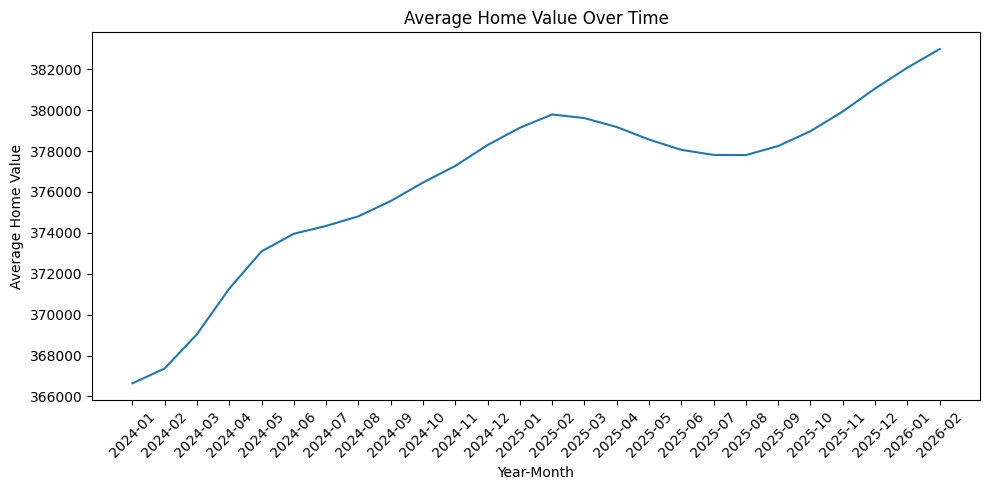

In [29]:
#Average home value over time
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(monthly_summary['year_month'], monthly_summary['home_value'])
plt.xticks(rotation=45)
plt.title('Average Home Value Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Average Home Value')
plt.tight_layout()
plt.show()

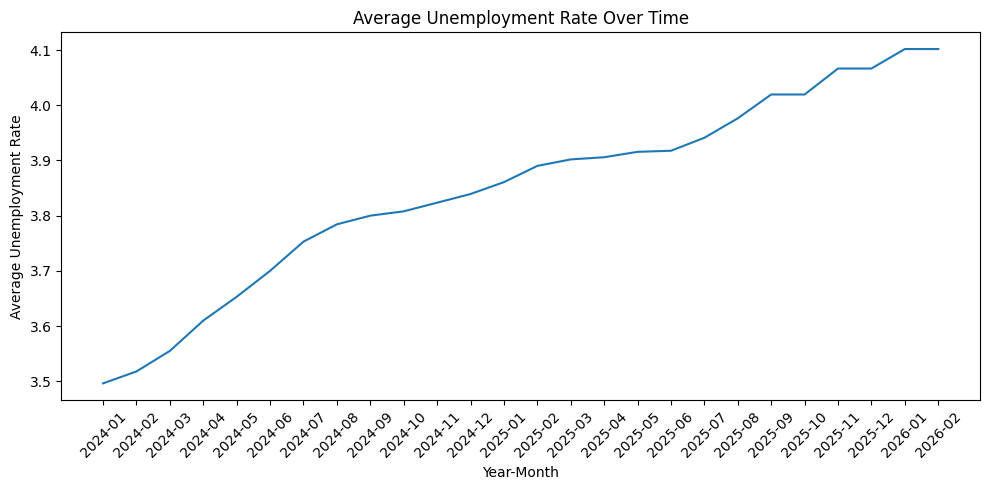

In [30]:
#Average unemployment rate over time
plt.figure(figsize=(10, 5))
plt.plot(monthly_summary['year_month'], monthly_summary['unemployment_rate'])
plt.xticks(rotation=45)
plt.title('Average Unemployment Rate Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Average Unemployment Rate')
plt.tight_layout()
plt.show()

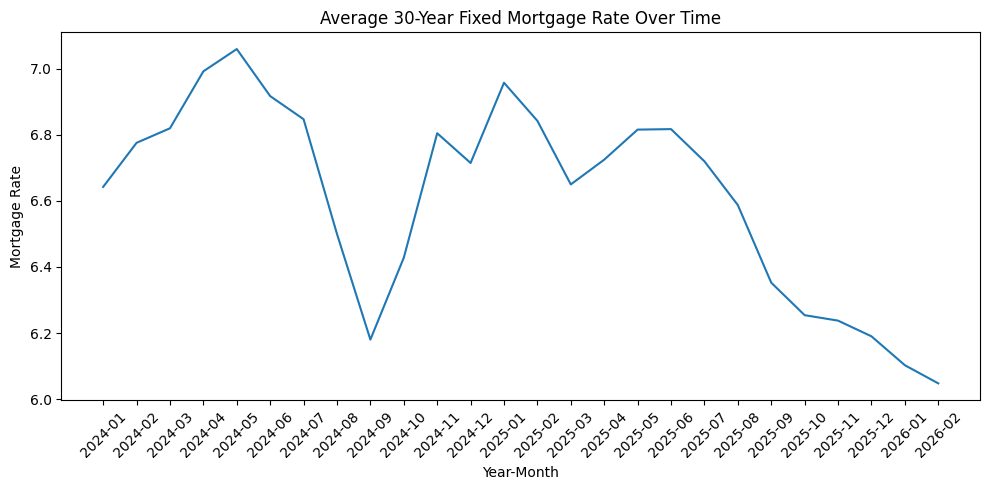

In [31]:
#Average mortgage rate over time
plt.figure(figsize=(10, 5))
plt.plot(monthly_summary['year_month'], monthly_summary['mortgage_rate'])
plt.xticks(rotation=45)
plt.title('Average 30-Year Fixed Mortgage Rate Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Mortgage Rate')
plt.tight_layout()
plt.show()

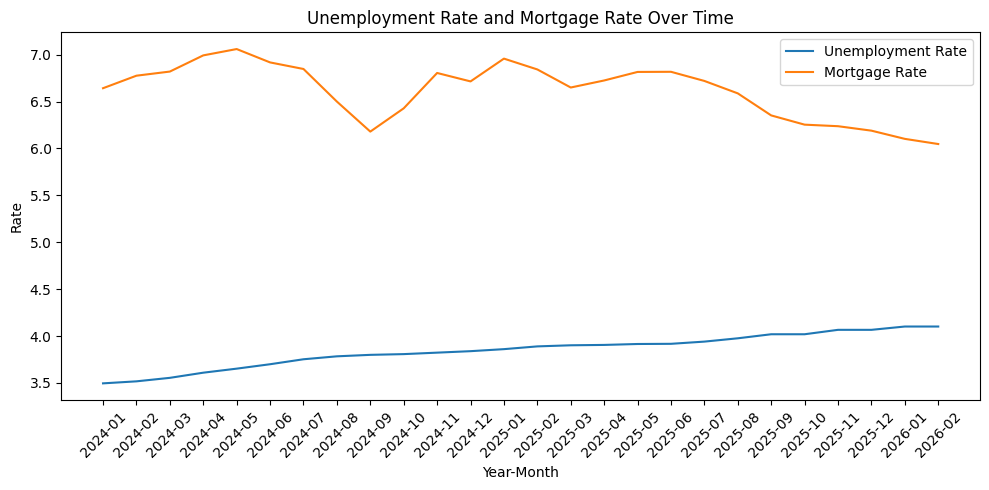

In [32]:
#Unemployment rate and mortgage rate together
plt.figure(figsize=(10, 5))
plt.plot(monthly_summary['year_month'], monthly_summary['unemployment_rate'], label='Unemployment Rate')
plt.plot(monthly_summary['year_month'], monthly_summary['mortgage_rate'], label='Mortgage Rate')

plt.xticks(rotation=45)
plt.title('Unemployment Rate and Mortgage Rate Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Rate')
plt.legend()
plt.tight_layout()
plt.show()

1. Mortgage rates stayed elevated throughout the study period.
Although mortgage rates eased slightly toward the end of the period, they remained above 6% for most months, suggesting that borrowing costs stayed relatively high and continued to put pressure on housing affordability.

2. Unemployment rates were comparatively stable, but showed a mild upward trend.
Average unemployment rose gradually from around 3.5% to just above 4.0%, indicating that labor market conditions softened slightly over time, which could further affect households’ purchasing capacity.

3. Housing affordability pressure likely persisted because mortgage rates remained high while labor market conditions did not improve.
The chart suggests that even though mortgage rates declined a bit in late 2025, they were still elevated, while unemployment did not fall. This combination implies that affordability challenges were unlikely to ease substantially.

4. The gap between mortgage rates and unemployment rates remained wide across the whole period.
This highlights that financing conditions were consistently much tighter than labor market conditions alone would suggest, reinforcing the idea that mortgage costs were a major constraint in the housing market.

##EDA 2 In the latest available month 2026-02, which states had the highest home values?

In [33]:
# Find the latest available month
latest_month = master_df_imputed['year_month'].max()

# Keep only the latest month
latest_df = master_df_imputed[master_df_imputed['year_month'] == latest_month].copy()

# Get the top 10 states by home value
top10_expensive = latest_df.sort_values('home_value', ascending=False).head(10)

# Display the result table
top10_expensive[['state', 'home_value']]

,state,home_value
1314,Hawaii,831892.749225
1275,California,775286.636344
1289,Massachusetts,655957.130778
1287,Washington,602276.610528
1323,District of Columbia,585099.753784
1285,New Jersey,567000.084899
1295,Colorado,543962.202614
1304,Utah,538478.432834
1315,New Hampshire,506968.835334
1278,New York,505147.795630


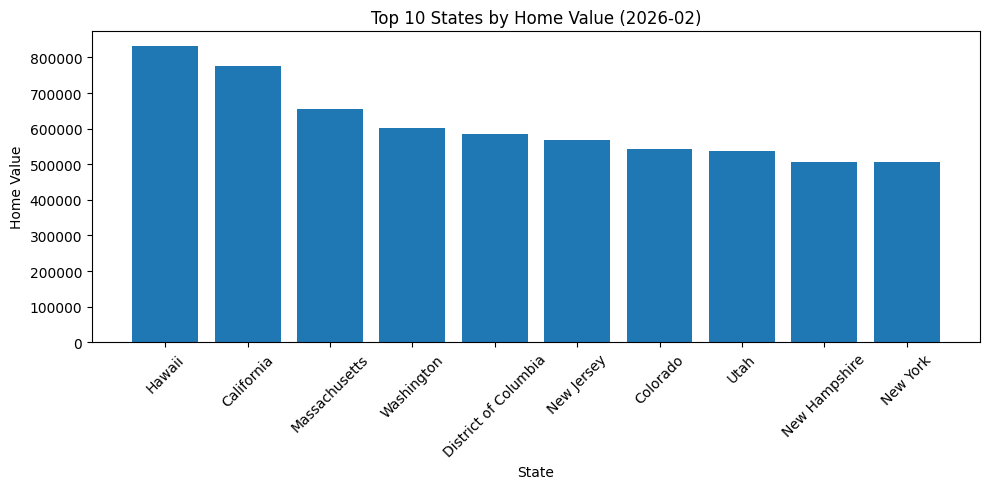

In [34]:
plt.figure(figsize=(10, 5))
plt.bar(top10_expensive['state'], top10_expensive['home_value'])
plt.xticks(rotation=45)
plt.title(f'Top 10 States by Home Value ({latest_month})')
plt.xlabel('State')
plt.ylabel('Home Value')
plt.tight_layout()
plt.show()

Inisghts: The latest-month comparison shows that the highest home values were concentrated in a relatively small group of states, led by Hawaii and California. This suggests that housing affordability pressure is not evenly distributed across the U.S., but is especially severe in a number of high-cost markets.

##EDA 3 Home Value Comparison for the Top 10 Highest-Value States (2024-01 vs 2026-01)

In [35]:
# Use the top 10 highest-value states from the latest month
latest_month = master_df_imputed['year_month'].max()
latest_df = master_df_imputed[master_df_imputed['year_month'] == latest_month].copy()
top10_expensive = latest_df.sort_values('home_value', ascending=False).head(10)

top10_states = top10_expensive['state'].tolist()

# Keep only those states for the two comparison months
compare_df = master_df_imputed[
    (master_df_imputed['state'].isin(top10_states)) &
    (master_df_imputed['year_month'].isin(['2024-01', '2026-01']))
][['state', 'year_month', 'home_value']].copy()

compare_df.head(10)

,state,year_month,home_value
0,California,2024-01,766370.813897
3,New York,2024-01,452046.162203
10,New Jersey,2024-01,508103.306116
12,Washington,2024-01,582324.036683
14,Massachusetts,2024-01,613049.182020
20,Colorado,2024-01,552611.216322
29,Utah,2024-01,514904.422219
39,Hawaii,2024-01,835936.596883
40,New Hampshire,2024-01,463806.088107
48,District of Columbia,2024-01,616586.217912


In [36]:
# Reshape into a wide comparison table
compare_pivot = compare_df.pivot(
    index='state',
    columns='year_month',
    values='home_value'
).reset_index()

# Calculate percentage growth
compare_pivot['growth_pct'] = (
    (compare_pivot['2026-01'] - compare_pivot['2024-01']) / compare_pivot['2024-01'] * 100
)

# Sort by 2026-01 home value
compare_pivot = compare_pivot.sort_values('2026-01', ascending=False)

compare_pivot

year_month,state,2024-01,2026-01,growth_pct
3,Hawaii,835936.596883,831354.528440,-0.548136
0,California,766370.813897,774927.326494,1.116498
4,Massachusetts,613049.182020,654682.436586,6.791177
9,Washington,582324.036683,601978.174635,3.375121
2,District of Columbia,616586.217912,586048.253315,-4.952748
6,New Jersey,508103.306116,564630.407640,11.125120
1,Colorado,552611.216322,545073.339530,-1.364047
8,Utah,514904.422219,537470.968467,4.382667
5,New Hampshire,463806.088107,506146.829017,9.128975
7,New York,452046.162203,502770.061083,11.220956


Insights: A comparison between January 2024 and January 2026 shows that most of the highest-value states remained expensive and several became even more costly over time. In particular, New York, New Jersey, and New Hampshire recorded notable growth, while Massachusetts and Utah also increased. By contrast, Hawaii, the District of Columbia, and Colorado experienced slight declines, but still remained among the highest-cost markets. Overall, the results suggest that affordability pressure persisted in already expensive states rather than shifting away from them.

##EDA 4 Top 10 lowest-value states in the latest month

In [37]:
latest_month = master_df_imputed['year_month'].max()

# Keep only the latest month
latest_df = master_df_imputed[master_df_imputed['year_month'] == latest_month].copy()

# Get the 10 states with the lowest home values
bottom10_states = latest_df.sort_values('home_value', ascending=True).head(10)

# Display the result table
bottom10_states[['state', 'home_value']]

,state,home_value
1313,West Virginia,173621.446033
1308,Mississippi,191571.757723
1299,Louisiana,210675.603496
1302,Oklahoma,219893.829856
1307,Arkansas,221041.287433
1305,Iowa,230833.413336
1300,Kentucky,231503.749546
1298,Alabama,235576.478245
1281,Ohio,241283.558812
1309,Kansas,244246.237972


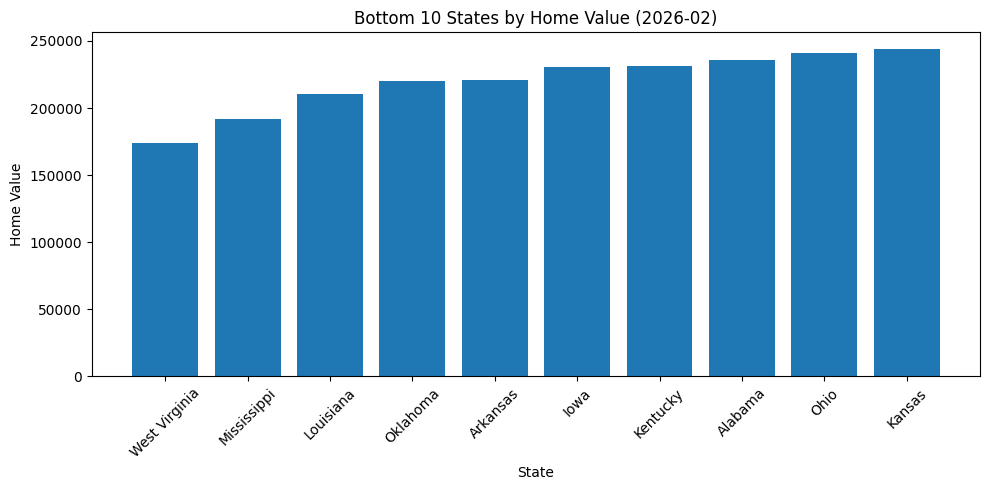

In [38]:
plt.figure(figsize=(10, 5))
plt.bar(bottom10_states['state'], bottom10_states['home_value'])
plt.xticks(rotation=45)
plt.title(f'Bottom 10 States by Home Value ({latest_month})')
plt.xlabel('State')
plt.ylabel('Home Value')
plt.tight_layout()
plt.show()

Insights: The latest-month comparison shows that the lowest-cost states remain far below the highest-cost states in terms of home values, highlighting strong geographic inequality in housing costs across the U.S. This suggests that housing affordability challenges are likely to vary substantially by state rather than being uniform nationwide.

##EDA 5 Home value vs unemployment rate in the latest month

In [39]:
# Examine the relationship between home value and unemployment rate
# in the latest available month to explore whether higher-cost housing markets are associated with weaker labor market conditions.

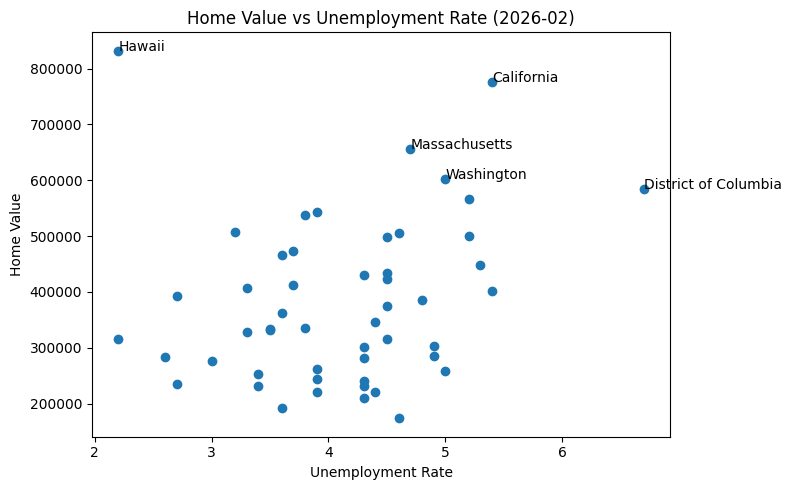

In [40]:
# Find the latest available month
latest_month = master_df_imputed['year_month'].max()

# Keep only the latest month
latest_df = master_df_imputed[master_df_imputed['year_month'] == latest_month].copy()

latest_df[['state', 'home_value', 'unemployment_rate']].head()


# Scatter plot with labels for the top 5 highest-value states
plt.figure(figsize=(8, 5))
plt.scatter(latest_df['unemployment_rate'], latest_df['home_value'])

for _, row in latest_df.nlargest(5, 'home_value').iterrows():
    plt.annotate(row['state'], (row['unemployment_rate'], row['home_value']))

plt.title(f'Home Value vs Unemployment Rate ({latest_month})')
plt.xlabel('Unemployment Rate')
plt.ylabel('Home Value')
plt.tight_layout()
plt.show()

Insights: The relationship between home value and unemployment rate appears weak or mixed rather than clearly negative. This suggests that expensive housing markets can still face moderate unemployment, meaning that affordability pressure is likely driven not only by labor market conditions but also by persistently high housing prices and borrowing costs (E.g. California, District of Columbia, Washington DC)

Labor market conditions alone did not explain housing costs. Some states still had very high home values even when unemployment was not especially high. This suggests that housing affordability was influenced by more than just employment conditions.

#Cleaning, Impute and Merge the Income Dataset

In [41]:
# Read the state income dataset
income_path = os.path.join(folder_path, 'state_income.csv')
df_income = pd.read_csv(income_path)

print(df_income.shape)
df_income.head()

(51, 3)


,State,Income_2023,Income_2024
0,Alabama,64040,66659
1,Alaska,89176,95665
2,Arizona,79587,81486
3,Arkansas,60425,62106
4,California,98328,100149


In [42]:
# Rename columns for easier merging
df_income = df_income.rename(columns={
    'State': 'state',
    'Income_2023': 'income_2023',
    'Income_2024': 'income_2024'
})

print(df_income.columns.tolist())
df_income.head()

['state', 'income_2023', 'income_2024']


,state,income_2023,income_2024
0,Alabama,64040,66659
1,Alaska,89176,95665
2,Arizona,79587,81486
3,Arkansas,60425,62106
4,California,98328,100149


In [43]:
# Merge annual income data into the imputed master dataset
master_df_imputed = master_df_imputed.merge(
    df_income,
    on='state',
    how='left'
)

print(master_df_imputed.shape)
print(master_df_imputed[['state', 'year', 'income_2023', 'income_2024']].head())
print(master_df_imputed[['income_2023', 'income_2024']].isna().sum())

(1326, 16)
          state  year  income_2023  income_2024
0    California  2024        98328       100149
1         Texas  2024        78006        79721
2       Florida  2024        75465        77735
3      New York  2024        84507        85820
4  Pennsylvania  2024        75993        77545
income_2023    0
income_2024    0
dtype: int64


In [45]:
# Create a lagged income column based on realistic data availability:
# use 2023 income for 2024 records,
# and 2024 income for 2025–2026 records.

import numpy as np

master_df_imputed['median_household_income_lagged'] = np.where(
    master_df_imputed['year'] == 2024,
    master_df_imputed['income_2023'],
    master_df_imputed['income_2024']
)

master_df_imputed[['state', 'year_month', 'year', 'income_2023', 'income_2024', 'median_household_income_lagged']].head(12)

,state,year_month,year,income_2023,income_2024,median_household_income_lagged
0,California,2024-01,2024,98328,100149,98328
1,Texas,2024-01,2024,78006,79721,78006
2,Florida,2024-01,2024,75465,77735,75465
3,New York,2024-01,2024,84507,85820,84507
4,Pennsylvania,2024-01,2024,75993,77545,75993
5,Illinois,2024-01,2024,82666,83211,82666
6,Ohio,2024-01,2024,69761,72212,69761
7,Georgia,2024-01,2024,76825,79991,76825
8,North Carolina,2024-01,2024,72884,73958,72884
9,Michigan,2024-01,2024,71216,72389,71216


##Quick EDA Lagged household income vs home value in the latest month

2026-02
             state year_month     home_value  median_household_income_lagged
1275    California    2026-02  775286.636344                          100149
1276         Texas    2026-02  301244.070183                           79721
1277       Florida    2026-02  375565.265605                           77735
1278      New York    2026-02  505147.795630                           85820
1279  Pennsylvania    2026-02  282198.523896                           77545


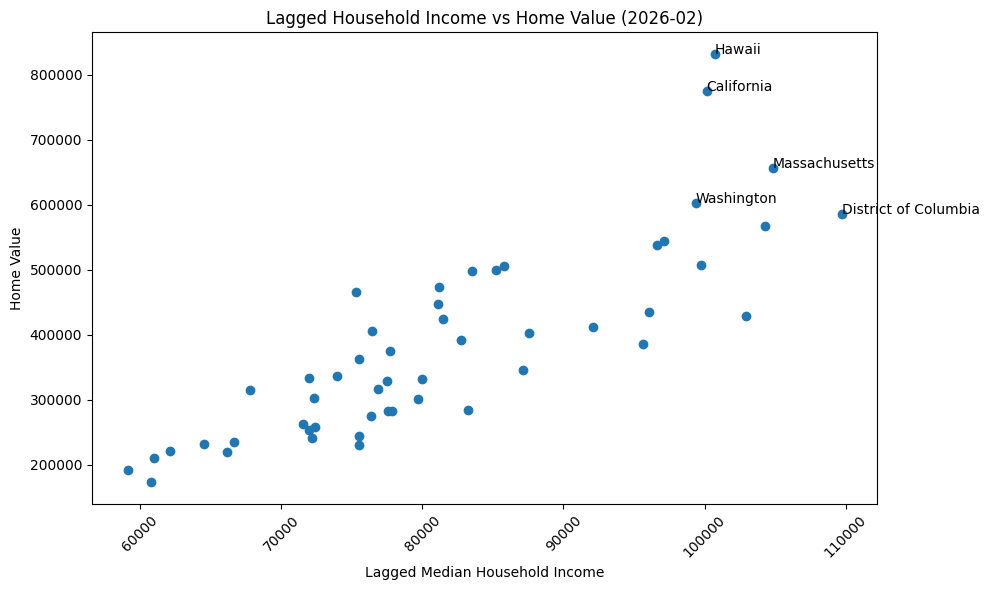

Correlation: 0.838


In [46]:
# Get the latest available month
latest_month = master_df_imputed['year_month'].max()

# Filter latest-month data
latest_income_df = master_df_imputed[
    master_df_imputed['year_month'] == latest_month
].copy()

# Quick check
print(latest_month)
print(latest_income_df[['state', 'year_month', 'home_value', 'median_household_income_lagged']].head())

# Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(
    latest_income_df['median_household_income_lagged'],
    latest_income_df['home_value']
)

# Label a few highest home-value states
top_states = latest_income_df.nlargest(5, 'home_value')
for _, row in top_states.iterrows():
    plt.text(
        row['median_household_income_lagged'],
        row['home_value'],
        row['state']
    )

plt.title(f'Lagged Household Income vs Home Value ({latest_month})')
plt.xlabel('Lagged Median Household Income')
plt.ylabel('Home Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Correlation
corr = latest_income_df[['median_household_income_lagged', 'home_value']].corr().iloc[0, 1]
print("Correlation:", round(corr, 3))

Insights: The scatter plot suggests a strong positive relationship between lagged household income and home value across states in the latest available month. States with higher lagged household income generally also had higher home values. However, high income did not necessarily imply better affordability, because many of the highest-income states were also among the most expensive housing markets.

#Export Ready to Use Datasets

In [44]:
import os
print(folder_path)
print(os.listdir(folder_path))

/content/drive/MyDrive/Colab Notebooks/DVN 36104/Datasets
['State_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv', 'mortgage_rate_30yr_us_weekly_2024_2026.csv', 'state_employment_unemployment_bls_monthly.xlsx', 'master_housing_affordability_dataset_full.csv', 'master_housing_affordability_dataset_aligned.csv', 'master_housing_affordability_dataset_full.gsheet', 'state_income.csv']


In [47]:
master_df_imputed.head()

,state,date,home_value,year,month,year_month,civilian_population,labor_force_total,labor_force_participation_rate,employment_total,employment_population_ratio,unemployment_total,unemployment_rate,mortgage_rate,income_2023,income_2024,median_household_income_lagged
0,California,2024-01-31,766370.813897,2024,1,2024-01,31535823.0,19611227.0,62.2,18607378.0,59.0,1003849.0,5.1,6.6425,98328,100149,98328
1,Texas,2024-01-31,308842.571167,2024,1,2024-01,23875494.0,15429166.0,64.6,14818390.0,62.1,610776.0,4.0,6.6425,78006,79721,78006
2,Florida,2024-01-31,400358.633247,2024,1,2024-01,18878106.0,11100291.0,58.8,10751001.0,56.9,349290.0,3.1,6.6425,75465,77735,75465
3,New York,2024-01-31,452046.162203,2024,1,2024-01,16243346.0,9894797.0,60.9,9485047.0,58.4,409750.0,4.1,6.6425,84507,85820,84507
4,Pennsylvania,2024-01-31,263290.887304,2024,1,2024-01,10569867.0,6609810.0,62.5,6365227.0,60.2,244583.0,3.7,6.6425,75993,77545,75993


In [48]:
master_df_imputed.to_csv(
    os.path.join(folder_path, 'master_housing_affordability_dataset_imputed.csv'),
    index=False
)

print("Imputed master dataset exported successfully.")

Imputed master dataset exported successfully.
